In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
wt_seq = "MLTPKKWLLGVLVVSGMLGAQKTNAVPRPKLVVGLVVDQMRWDYLYRYYSKYGEGGFKRMLNTGYSLNNVHIDYVPTVTAIGHTSIFTGSVPSIHGIAGNDWYDKELGKSVYCTSDETVQPVGTTSNSVGQHSPRNLWSTTVTDQLGLATNFTSKVVGVSLKDRASILPAGHNPTGAFWFDDTTGKFITSTYYTKELPKWVNDFNNKNVPAQLVANGWNTLLPINQYTESSEDNVEWEGLLGSKKTPTFPYTDLAKDYEAKKGLIRTTPFGNTLTLQMADAAIDGNQMGVDDITDFLTVNLASTDYVGHNFGPNSIEVEDTYLRLDRDLADFFNNLDKKVGKGNYLVFLSADHGAAHSVGFMQAHKMPTGFFVEDMKKEMNAKLKQKFGADNIIAAAMNYQVYFDRKVLADSKLELDDVRDYVMTELKKEPSVLYVLSTDEIWESSIPEPIKSRVINGYNWKRSGDIQIISKDGYLSAYSKKGTTHSVWNSYDSHIPLLFMGWGIKQGESNQPYHMTDIAPTVSSLLKIQFPSGAVGKPITEVIGR"
print(len(wt_seq))

546


In [15]:
raw_data = pd.read_csv("../raw_data/Markin_2021/Markin_2021.csv").set_index("variant")

In [6]:
# raw_data[['variant','kcat_cMUP_s-1','KM_cMUP_uM', 'kcatOverKM_cMUP_M-1s-1',
#          'kcatOverKM_MeP_M-1s-1', 'kcatOverKM_MecMUP_M-1s-1', 'kcatOverKM_MePkchem_M-1s-1']].set_index("variant")

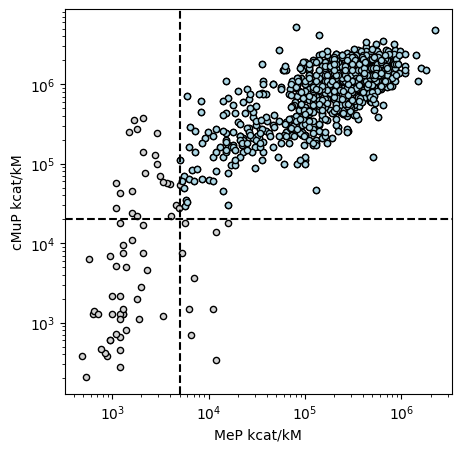

In [48]:
plt.figure(figsize=(5,5))

y1 = 'kcatOverKM_MeP_M-1s-1'
y2 = 'kcatOverKM_cMUP_M-1s-1'

raw_data_filt = raw_data.loc[(raw_data[y1]>5000)&(raw_data[y2]>20000)]

plt.scatter(raw_data['kcatOverKM_MeP_M-1s-1'], raw_data['kcatOverKM_cMUP_M-1s-1'], ec='k', c='lightgray', s=20)
plt.scatter(raw_data_filt['kcatOverKM_MeP_M-1s-1'], raw_data_filt['kcatOverKM_cMUP_M-1s-1'], ec='k', c='lightblue', s=20)

plt.xscale('log'); plt.yscale('log')

plt.xlabel('MeP kcat/kM')
plt.ylabel('cMuP kcat/kM')

plt.axvline(5000, c='k', ls='--')
plt.axhline(20000, c='k', ls='--')

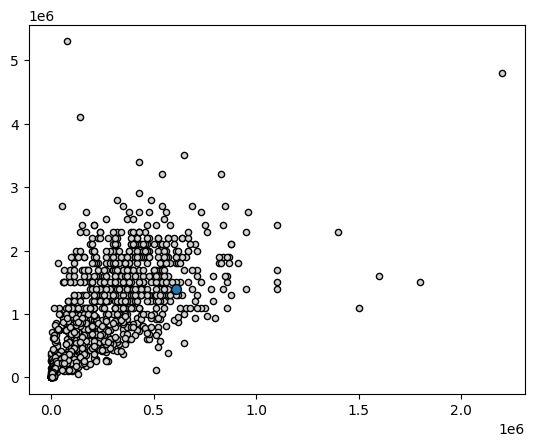

In [17]:
plt.scatter(raw_data['kcatOverKM_MeP_M-1s-1'], raw_data['kcatOverKM_cMUP_M-1s-1'], s=20, ec='k', c='lightgray')
plt.scatter(raw_data.loc['WT']['kcatOverKM_MeP_M-1s-1'], raw_data.loc['WT']['kcatOverKM_cMUP_M-1s-1'], ec='k', s=50)

In [19]:
def get_variant(reference, mutations, start_index=1):

    if isinstance(reference, (str, np.str_)):
        reference = np.array(list(reference))
        return_as_string = True
    
    variant = reference.copy()
    for mut in mutations:
        if mut!='WT':
            pos = int(mut[1:-1])-start_index
            variant[pos] = mut[-1]

    if return_as_string:
        return ''.join(variant)
    else:   
        return variant

raw_data['aa_seq'] = [get_variant(wt_seq, _id.split('/')) for _id in raw_data.index]

In [26]:
raw_data = raw_data.rename({"WT":"M1M"})

In [60]:
raw_data['mutant'] = raw_data.index
raw_data['mutated_sequence'] = raw_data.aa_seq

df1 = raw_data[['mutant', 'mutated_sequence', 'kcatOverKM_MeP_M-1s-1']]
df1['DMS_score'] = df1['kcatOverKM_MeP_M-1s-1']
df2 = raw_data[['mutant', 'mutated_sequence', 'kcatOverKM_cMUP_M-1s-1']]
df2['DMS_score'] = df2['kcatOverKM_cMUP_M-1s-1']

/tmp/ipykernel_1416776/1403914156.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['DMS_score'] = df1['kcatOverKM_MeP_M-1s-1']
/tmp/ipykernel_1416776/1403914156.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['DMS_score'] = df2['kcatOverKM_cMUP_M-1s-1']


In [61]:
df1.to_csv("../processed_data/ALPH_ELIME_Markin_2021/ALPH_ELIME_Markin_2021_MeP.csv")
df2.to_csv("../processed_data/ALPH_ELIME_Markin_2021/ALPH_ELIME_Markin_2021_cMUP.csv")

In [62]:
df1.to_csv("/n/groups/marks/users/sam/SpecificityStudio/DMS_assays/ALPH_ELIME_Markin_2021_MeP.csv")
df2.to_csv("/n/groups/marks/users/sam/SpecificityStudio/DMS_assays/ALPH_ELIME_Markin_2021_cMUP.csv")

In [57]:
ls /n/groups/marks/users/sam/SpecificityStudio/DMS_assays

 ALPH_ELIME_Markin_2021_MeP.csv
 MNTH_DEIRA_Berry_2025.csv
 MNTH_DEIRA_Berry_2025_Mg.csv
 MNTH_DEIRA_Berry_2025_Mn.csv
 NORA_STAAU_Miller_2025_acriflavine.csv
 NORA_STAAU_Miller_2025.csv
 NORA_STAAU_Miller_2025_ethidium.csv
'NORA_STAAU_Miller_2025_no drug.csv'
 NORA_STAAU_Miller_2025_norfloxacin.csv
 NORA_STAAU_Miller_2025_ofloxacin.csv
 NORA_STAAU_Miller_2025_pentamidine.csv
'NORA_STAAU_Miller_2025_pipemidic acid.csv'
 NORA_STAAU_Miller_2025_puromycin.csv
 NORA_STAAU_Miller_2025_TPP.csv
 PHO4_YEAST_Aditham_2021_ACACGTGA.csv
 PHO4_YEAST_Aditham_2021_CAACGTG.csv
 PHO4_YEAST_Aditham_2021_CACGTT.csv
 PHO4_YEAST_Aditham_2021_CATGTG.csv
 PHO4_YEAST_Aditham_2021_CCACGCGA.csv
 PHO4_YEAST_Aditham_2021_CCACGTGA.csv
 PHO4_YEAST_Aditham_2021_CGCGTG.csv
 PHO4_YEAST_Aditham_2021.csv
 PHO4_YEAST_Aditham_2021_GCACGTGC.csv
 PHO4_YEAST_Aditham_2021_TCACGTGC.csv
